---
## Ejercicio 1
---

In [ ]:
# ============================================
# Tema: Introducción a Pricing y Python
# Código: Unir base de vigor y siniestros (R → Python)
# Requiere: pandas (>=1.5), numpy
# ============================================
#%%
import os
import numpy as np
import pandas as pd

In [12]:
# -------------------------------------------------------------------
# 0) Configuración de ruta de trabajo (similar a setwd(dir) en R)
# -------------------------------------------------------------------
# Si lo corres como script .py:
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Si estás en un notebook, toma el cwd
    BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(BASE_DIR, "data")

# Limpieza de entorno no aplica igual que en R; en Python no es necesario rm(list=ls())

In [13]:

# -------------------------------------------------------------------
# 1) Vigor
# -------------------------------------------------------------------
vigor_path = os.path.join(DATA_DIR, r"vigor.csv")
vigor = pd.read_csv(vigor_path)

print("\n[glimpse(vigor)]")
print(vigor.info())
print(vigor.head(3))


[glimpse(vigor)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NUMPOL               50000 non-null  int64  
 1   EXPO                 50000 non-null  float64
 2   ZONA                 50000 non-null  object 
 3   POTENCIA             50000 non-null  int64  
 4   ANTIGUEDAD_VEHICULO  50000 non-null  int64  
 5   EDAD_CONDUCTOR       50000 non-null  int64  
 6   BONO                 50000 non-null  int64  
 7   MARCA                50000 non-null  int64  
 8   COMBUSTIBLE          50000 non-null  object 
 9   DENSIDAD             50000 non-null  int64  
 10  REGION               50000 non-null  int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 4.2+ MB
None
   NUMPOL  EXPO ZONA  POTENCIA  ANTIGUEDAD_VEHICULO  EDAD_CONDUCTOR  BONO  \
0      27  0.87    C         7                    0              56    50   
1 

In [14]:

# Primera verificación general
vigor_summary = pd.DataFrame({
    "polizas": [vigor["NUMPOL"].nunique()],
    "registros": [len(vigor)],
    "expo": [vigor["EXPO"].sum()]
})
print("\n[Verificación vigor]")
print(vigor_summary)



[Verificación vigor]
   polizas  registros          expo
0    50000      50000  26431.132502


In [15]:

# -------------------------------------------------------------------
# 2) Siniestros
# -------------------------------------------------------------------
siniestros_path = os.path.join(DATA_DIR, "siniestros.csv")
siniestros_raw = pd.read_csv(siniestros_path)

print("\n[glimpse(siniestros)]")
print(siniestros_raw.info())
print(siniestros_raw.head(3))


[glimpse(siniestros)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7569 entries, 0 to 7568
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             7569 non-null   int64  
 1   NUMPOL         7569 non-null   int64  
 2   COD_COBERTURA  7569 non-null   object 
 3   MONTO          7569 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 236.7+ KB
None
   ID   NUMPOL COD_COBERTURA   MONTO
0   6  4075803           2DO  512.74
1   7  4075803           1RC    0.00
2  14  4024277           2DO   89.70


In [16]:

# Primer check
sin_check_1 = pd.DataFrame({
    "polizas": [siniestros_raw["NUMPOL"].nunique()],
    "registros": [len(siniestros_raw)],
    "id_claim": [siniestros_raw["ID"].nunique()] if "ID" in siniestros_raw.columns else [np.nan],
    "coberturas": [siniestros_raw["COD_COBERTURA"].nunique()],
    "polizas_cobertura": [siniestros_raw[["NUMPOL","COD_COBERTURA"]].drop_duplicates().shape[0]]
})
print("\n[Primer check siniestros (sin filtros)]")
print(sin_check_1)



[Primer check siniestros (sin filtros)]
   polizas  registros  id_claim  coberturas  polizas_cobertura
0     5709       7569      7569           6               7122


In [17]:
# Nunca olvidar este paso: revisar montos <= 0
siniestros_le0 = siniestros_raw.query("MONTO <= 0")
if len(siniestros_le0) > 0:
    print("\n[Advertencia] Existen registros con MONTO <= 0 (muestra):")
    print(siniestros_le0.head(10))
else:
    print("\n[OK] No hay registros con MONTO <= 0.")


[Advertencia] Existen registros con MONTO <= 0 (muestra):
     ID   NUMPOL COD_COBERTURA   MONTO
1     7  4075803           1RC    0.00
10  122  4017796           1RC    0.00
24  276  4024819           2DO -878.92
25  323  4049118           2DO -285.77
36  472  4036985           2DO -565.46
46  512  4006854           2DO -764.77
47  513  4006854           1RC    0.00
50  530  1011874           2DO -237.01
51  554  4042992           4BG    0.00
53  606  4017028           2DO    0.00


In [18]:
# Segundo check con datos limpios (MONTO > 0)
siniestros_pos = siniestros_raw.query("MONTO > 0").copy()
sin_check_2 = pd.DataFrame({
    "polizas": [siniestros_pos["NUMPOL"].nunique()],
    "registros": [len(siniestros_pos)],
    "coberturas": [siniestros_pos["COD_COBERTURA"].nunique()],
    "id_claim": [siniestros_pos[["NUMPOL","COD_COBERTURA"]].drop_duplicates().shape[0]]
})
print("\n[Segundo check siniestros (MONTO > 0)]")
print(sin_check_2)


[Segundo check siniestros (MONTO > 0)]
   polizas  registros  coberturas  id_claim
0     4965       6196           6      5907


In [19]:
# Análisis a nivel cobertura: detectar duplicados por NUMPOL, COD_COBERTURA
dup_mask = siniestros_pos.duplicated(subset=["NUMPOL", "COD_COBERTURA"], keep=False)
siniestros_dups = siniestros_pos.loc[dup_mask].sort_values(["NUMPOL","COD_COBERTURA"])
if len(siniestros_dups) > 0:
    print("\n[Info] Existen póliza-cobertura con múltiples registros (muestra):")
    print(siniestros_dups.head(10))
else:
    print("\n[OK] No hay duplicados por póliza-cobertura.")


[Info] Existen póliza-cobertura con múltiples registros (muestra):
         ID  NUMPOL COD_COBERTURA    MONTO
1199  16127    6375           2DO    83.80
1310  17474    6375           2DO  3348.50
2240  30859   24992           1RC  1128.12
2245  30896   24992           1RC  1128.12
7103  99033   38527           4BG   122.33
7107  99077   38527           4BG   211.62
1993  27040   39463           1RC   113.96
3382  45812   39463           1RC  1128.12
4754  65336   39782           2DO  1320.34
6004  83075   39782           2DO   423.90


In [20]:
# Agregación a nivel póliza-cobertura: suma MONTO y cuenta siniestros
siniestros = (
    siniestros_pos
    .groupby(["NUMPOL","COD_COBERTURA"], as_index=False)
    .agg(MONTO=("MONTO","sum"), num_sin=("MONTO","size"))
)

sin_post_agg = pd.DataFrame({
    "polizas": [siniestros["NUMPOL"].nunique()],
    "registros": [len(siniestros)],
    "coberturas": [siniestros["COD_COBERTURA"].nunique()],
    "id_claim": [siniestros[["NUMPOL","COD_COBERTURA"]].drop_duplicates().shape[0]]
})
print("\n[Post-aggregación siniestros]")
print(sin_post_agg)


[Post-aggregación siniestros]
   polizas  registros  coberturas  id_claim
0     4965       5907           6      5907


In [21]:
# Filtramos cobertura a modelar (ejemplo: "1RC")
siniestros = siniestros.query('COD_COBERTURA == "1RC"').copy()
print("\n[Filtrado cobertura == '1RC'] Registros:", len(siniestros))


[Filtrado cobertura == '1RC'] Registros: 1803


In [22]:
# -------------------------------------------------------------------
# 3) Join final
# -------------------------------------------------------------------
# Left join por NUMPOL
base_trabajo = vigor.merge(siniestros, how="left", on="NUMPOL")

# Validaciones finales
final_summary = pd.DataFrame({
    "polizas": [base_trabajo["NUMPOL"].nunique()],
    "registros": [len(base_trabajo)],
    "MONTO": [base_trabajo["MONTO"].sum(skipna=True)],
    "num_sin": [base_trabajo["num_sin"].sum(skipna=True)]
})
print("\n[Validación final base_trabajo]")
print(final_summary)

# Revisar nulos en num_sin (no siniestradas)
print("\n[Ejemplo de NUMPOL y num_sin (muestra)]")
print(base_trabajo.loc[:, ["NUMPOL","num_sin"]].head())


[Validación final base_trabajo]
   polizas  registros       MONTO  num_sin
0    50000      50000  3729978.73   1924.0

[Ejemplo de NUMPOL y num_sin (muestra)]
   NUMPOL  num_sin
0      27      NaN
1     115      NaN
2     121      NaN
3     142      NaN
4     155      NaN


In [23]:

# Reemplazar NA por 0 en num_sin (equiv. replace_na de R)
base_trabajo["num_sin"] = base_trabajo["num_sin"].fillna(0).astype(int)
print("\n[Base de trabajo final (muestra)]")
print(base_trabajo.head(10))



[Base de trabajo final (muestra)]
   NUMPOL  EXPO ZONA  POTENCIA  ANTIGUEDAD_VEHICULO  EDAD_CONDUCTOR  BONO  \
0      27  0.87    C         7                    0              56    50   
1     115  0.72    D         5                    0              45    50   
2     121  0.05    C         6                    0              37    55   
3     142  0.90    C        10                   10              42    50   
4     155  0.12    C         7                    0              59    50   
5     186  0.83    C         5                    0              75    50   
6     217  0.74    A         5                    4              31    64   
7     285  0.09    F         5                    0              41    90   
8     303  0.77    B         4                    0              42    50   
9     337  0.24    A         4                    0              29    76   

   MARCA COMBUSTIBLE  DENSIDAD  REGION COD_COBERTURA  MONTO  num_sin  
0     12           D        93      13        

In [25]:
# Guardar salida (equivalente a RDS → usamos pickle por conservar tipos)
out_path = os.path.join(DATA_DIR, "base_trabajo.pkl")
base_trabajo.to_pickle(out_path)
print(f"\n[Guardado] base_trabajo → {out_path}")


[Guardado] base_trabajo → c:\Users\jon\Downloads\practica2\data\base_trabajo.pkl


In [26]:

# (Opcional) Exportar también a CSV limpio
base_trabajo.to_csv(os.path.join(DATA_DIR, r"BaseTrabajo.csv"), index=False)

#%%

# 📘 Preguntas

### ¿Por qué es fundamental asegurar que la unión (merge) se haga sobre las mismas llaves (por ejemplo, estado, año, ramo)?

Al hacer el merge por llaves específicas (como estado, año o ramo), se estan construyendo "celdas de riesgo". Si las llaves no coinciden perfectamente, rompes la relación causal, es decir, estarías atribuyéndole el costo de los choques a pólizas que no los generaron, o midiendo exposición de vehículos que no están siendo evaluados.

Veamos qué pasa en las tablas cuando las llaves de cruce están sucias.

---

#### 1. Base de Exposición (Vigor)

| Estado      | Ramo  | Exposición (Años-Vehículo) |
|-------------|-------|----------------------------|
| Jalisco     | Taxis | 1,000                      |
| Nuevo León  | Taxis | 500                        |

---

#### 2. Base de Siniestros

| Estado      | Ramo  | Siniestros Reportados | Monto Pagado |
|-------------|-------|-----------------------|--------------|
| JAL         | Taxis | 150                   | $300,000     |
| Nuevo León  | Taxis | 80                    | $150,000     |

---

Fíjate en el primer registro:

- En la exposición el sistema de emisión dice **"Jalisco"**  
- Pero el ajustador registró los siniestros como **"JAL"**

---

#### 3. Resultado del Merge (Left Join)

Si haces un merge directo (`on=['Estado', 'Ramo']`), el sistema **no reconoce que "JAL" y "Jalisco" son lo mismo**.

El resultado será:

| Estado      | Ramo  | Exposición | Siniestros | Monto Total | Frecuencia (Sin/Expo) |
|-------------|-------|------------|------------|-------------|------------------------|
| Jalisco     | Taxis | 1,000      | 0          | $0          | 0.00%                  |
| Nuevo León  | Taxis | 500        | 80         | $150,000    | 16.00%                 |

---

#### 4. ¿Por qué esto destruye el modelo?

Aquí es donde se rompe la relación causal:

### Exposición sin siniestros (Falso positivo de rentabilidad)
El modelo pensará que los **1,000 taxis de Jalisco** son riesgo perfecto:

- No hubo siniestros
- Frecuencia = 0%

Si usas un **GLM Poisson**, el modelo aprenderá que:
> Estar en Jalisco reduce el riesgo a cero

---

###  Hay siniestros "fantasma"

Los **150 siniestros de "JAL"**:

- No hacen match en el merge
- Quedan fuera del dataset analítico

Pero en la realidad:
- Sí costaron **$300,000**
- Nadie los está pagando en la tarifa

---

#### 5. Conclusión

Se rompe la causalidad porque:

- Mides la **exposición en Jalisco**
- Pero **no le asignas sus propios siniestros**

---


### Explica con un ejemplo qué pasaría si en la base de siniestros aparece un estado que no está en la base de exposición.

Imagina que en tu base de siniestros tienes 15 accidentes graves registrados en el estado de "Oaxaca", pero en tu base de vigor (exposición), ese estado no existe (quizás porque ventas lo registró como "OAX", o la cartera se emitió bajo una oficina centralizada en "CDMX").

¿Qué pasa en el código al unirlas?

- Si haces un Left Join (desde la exposición): Esos 15 siniestros de Oaxaca simplemente desaparecen. Al no encontrar su llave en la base de pólizas, se quedan fuera del tablón analítico. Son siniestros "huérfanos".

- Si haces un Full Outer Join: El sistema creará una fila para Oaxaca que dirá: 15 siniestros, pero 0.0 años de exposición.

### ¿Cómo afectaría esto al cálculo de la frecuencia?

La frecuencia se define matemáticamente como:

$$
\text{Frecuencia} = \frac{\text{Número de Siniestros}}{\text{Exposición}}
$$

El error de las llaves desalineadas destruye este cálculo en dos niveles:

- A nivel celda (local): si usamos el escenario del Full Outer Join, para el ejemplo dado de Oaxaca, la fórmula sería:

  $$
  \text{Frecuencia} = \frac{15}{0}
  $$

  Esto es matemáticamente indefinido (arrojará un error de división por cero o un infinito en tu software). Es imposible modelar el riesgo (por ejemplo, con un GLM de Poisson) si la exposición de la celda es nula.

- A nivel cartera (global): si usamos el escenario del Left Join y los siniestros de Oaxaca se borran, la cantidad total de siniestros de la compañía baja artificialmente, pero la exposición global se mantiene igual. La frecuencia global estará subestimada.

Una frecuencia subestimada significa que calcularás una prima de riesgo más barata de lo que matemáticamente debería ser. La aseguradora asumirá el riesgo real en la calle, cobrará menos dinero por él, y generará una pérdida técnica garantizada.

---
## Modelos Lineales y GLM
---

## Respuesta: unión de siniestros y exposición

Asegurar que el merge se haga sobre las mismas llaves (por ejemplo, `estado`, `año`, `ramo`) es fundamental porque esas variables definen la **misma unidad de riesgo** en ambas tablas.

Si las llaves no coinciden exactamente, el cruce puede generar dos problemas graves:
- filas sin correspondencia (faltan exposiciones o faltan siniestros),
- duplicaciones involuntarias (muchos-a-muchos), inflando conteos y totales.

### Ejemplo: estado presente en siniestros pero ausente en exposición
Supón que en siniestros existe el registro (`estado = Oaxaca`, `año = 2024`, `ramo = Auto`) con 30 siniestros, pero ese mismo trío no existe en exposición.

Según el tipo de merge:
- `inner join`: ese registro se elimina del resultado final (desaparece).
- `left join` desde siniestros: quedará con exposición nula (`NaN`).

### Impacto en la frecuencia
La frecuencia suele calcularse como:

$$\text{Frecuencia} = \frac{\text{Número de siniestros}}{\text{Exposición}}$$

Con una llave sin match:
- si usas `inner join`, **subestimas** la frecuencia agregada porque pierdes siniestros al eliminar filas,
- si exposición queda en `NaN` o 0, la frecuencia queda indefinida, infinita o con error,
- si hay duplicaciones por llaves mal definidas, puedes **sobreestimar** o distorsionar la frecuencia.

Por eso, antes de modelar, se valida unicidad de llaves en cada base y se revisan los no-coincidentes (`anti-join`) para corregir catálogos, codificación o cobertura temporal.

In [ ]:
# =========================================================
# Ejemplo en estilo 02_lm_glm.py (pandas + statsmodels GLM)
# Objetivo: mostrar el impacto de una llave faltante en la frecuencia
# =========================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1) Bases de trabajo: siniestros y exposición
# ---------------------------------------------------------
siniestros = pd.DataFrame({
    'estado': ['CDMX', 'Jalisco', 'Oaxaca'],
    'año': [2024, 2024, 2024],
    'ramo': ['Auto', 'Auto', 'Auto'],
    'n_siniestros': [100, 50, 30]
})

# Oaxaca no existe en exposición (falla de llave)
exposicion = pd.DataFrame({
    'estado': ['CDMX', 'Jalisco'],
    'año': [2024, 2024],
    'ramo': ['Auto', 'Auto'],
    'exposicion': [10000, 5000]
})

llaves = ['estado', 'año', 'ramo']

print('--- Siniestros ---')
print(siniestros)
print('\n--- Exposición ---')
print(exposicion)

# ---------------------------------------------------------
# 2) Merge por llaves correctas
# ---------------------------------------------------------
m_inner = pd.merge(siniestros, exposicion, how='inner', on=llaves)
m_left = pd.merge(siniestros, exposicion, how='left', on=llaves)

print('\n--- Inner join (pierde Oaxaca) ---')
print(m_inner)
print('\n--- Left join (Oaxaca con NaN en exposición) ---')
print(m_left)

# ---------------------------------------------------------
# 3) Frecuencia observada
# ---------------------------------------------------------
freq_inner = m_inner['n_siniestros'].sum() / m_inner['exposicion'].sum()

m_left_valid = m_left.dropna(subset=['exposicion']).copy()
freq_left_valid = m_left_valid['n_siniestros'].sum() / m_left_valid['exposicion'].sum()

m_left_zero = m_left.copy()
m_left_zero['exposicion'] = m_left_zero['exposicion'].fillna(0)
m_left_zero['frecuencia'] = np.where(
    m_left_zero['exposicion'] > 0,
    m_left_zero['n_siniestros'] / m_left_zero['exposicion'],
    np.inf
)

print('\nFrecuencia global (inner):', round(freq_inner, 6))
print('Frecuencia global (left quitando NaN):', round(freq_left_valid, 6))
print('\nFrecuencia por fila en left imputando exposición=0:')
print(m_left_zero[['estado', 'n_siniestros', 'exposicion', 'frecuencia']])

# ---------------------------------------------------------
# 4) Escenario ideal: Oaxaca sí existe en exposición
# ---------------------------------------------------------
exposicion_ideal = pd.concat([
    exposicion,
    pd.DataFrame([{'estado': 'Oaxaca', 'año': 2024, 'ramo': 'Auto', 'exposicion': 3000}])
], ignore_index=True)

m_ideal = pd.merge(siniestros, exposicion_ideal, how='inner', on=llaves)
freq_ideal = m_ideal['n_siniestros'].sum() / m_ideal['exposicion'].sum()
print('\nFrecuencia global ideal (con Oaxaca):', round(freq_ideal, 6))

# ---------------------------------------------------------
# 5) Justificación con GLM Poisson (como en 02_lm_glm.py)
# ---------------------------------------------------------
# Modelo de conteos con offset(log(exposición))
glm_inner = smf.glm(
    'n_siniestros ~ 1',
    data=m_inner,
    family=sm.families.Poisson(sm.families.links.log()),
    offset=np.log(m_inner['exposicion'])
).fit()

glm_ideal = smf.glm(
    'n_siniestros ~ 1',
    data=m_ideal,
    family=sm.families.Poisson(sm.families.links.log()),
    offset=np.log(m_ideal['exposicion'])
).fit()

# En este GLM, exp(intercepto) representa la tasa (frecuencia)
tasa_inner_glm = float(np.exp(glm_inner.params['Intercept']))
tasa_ideal_glm = float(np.exp(glm_ideal.params['Intercept']))

print('\n--- GLM Poisson con offset(log(exposición)) ---')
print(f'Tasa estimada con inner (sin Oaxaca): {tasa_inner_glm:.6f}')
print(f'Tasa estimada ideal (con Oaxaca):     {tasa_ideal_glm:.6f}')

print('\nConclusión: al faltar una llave en exposición, el merge descarta o invalida filas y sesga la frecuencia estimada.')

--- Siniestros ---
    estado   año  ramo  n_siniestros
0     CDMX  2024  Auto           100
1  Jalisco  2024  Auto            50
2   Oaxaca  2024  Auto            30

--- Exposición ---
    estado   año  ramo  exposicion
0     CDMX  2024  Auto       10000
1  Jalisco  2024  Auto        5000

--- Inner join (pierde Oaxaca) ---
    estado   año  ramo  n_siniestros  exposicion
0     CDMX  2024  Auto           100       10000
1  Jalisco  2024  Auto            50        5000

--- Left join (Oaxaca con NaN en exposición) ---
    estado   año  ramo  n_siniestros  exposicion
0     CDMX  2024  Auto           100     10000.0
1  Jalisco  2024  Auto            50      5000.0
2   Oaxaca  2024  Auto            30         NaN

Frecuencia global (inner): 0.01
Frecuencia global (left quitando NaN): 0.01

Frecuencia por fila en left imputando exposición=0:
    estado  n_siniestros  exposicion  frecuencia
0     CDMX           100     10000.0        0.01
1  Jalisco            50      5000.0        0.01
2 

c:\Users\jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
c:\Users\jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may 

---
## Ejercicio 5 – AAR
---

# 5. Dispersión y elección de distribución (05_dispersion.py)

El script evalúa la sobredispesión y compara Poisson, Quasi-Poisson, Zero-Inflated y Binomial Negativa

{'m_N': np.float64(0.07279294596542157), 's2_N': np.float64(0.08778567195552542), 'dispersion': np.float64(1.2059639954292516)}

[EDA por COMBUSTIBLE]
   COMBUSTIBLE       m_N      s2_N          expo  dispersion
0           D  0.079715  0.087014  12519.548937    1.091560
1           E  0.066563  0.088421  13911.583565    1.328373

[WLS] s2_N ~ 0 + m_N, pesos=expo
                                 WLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.748
Model:                            WLS   Adj. R-squared (uncentered):              0.744
Method:                 Least Squares   F-statistic:                              239.9
Date:                Tue, 14 Apr 2026   Prob (F-statistic):                    6.23e-26
Time:                        22:38:43   Log-Likelihood:                          87.175
No. Observations:                  82   AIC:                                     -172.3
Df Residuals:     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['loglike_method']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



[NB2 discreto] (estima parámetro de dispersión)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['loglike_method']
  warnings.warn(msg, ValueWarning)


                     NegativeBinomialP Regression Results                     
Dep. Variable:                      y   No. Observations:                50000
Model:              NegativeBinomialP   Df Residuals:                    49998
Method:                           MLE   Df Model:                            1
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:               5.339e-05
Time:                        22:38:54   Log-Likelihood:                -8207.7
converged:                       True   LL-Null:                       -8208.1
Covariance Type:            nonrobust   LLR p-value:                    0.3492
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.1854      0.081    -39.548      0.000      -3.343      -3.028
EDAD_CONDUCTOR    -0.0016      0.002     -0.936      0.349      -0.005       0.002
alpha              2.6622      0.329

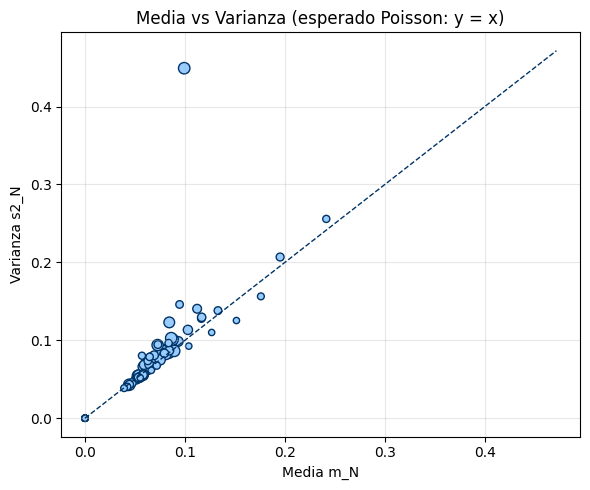

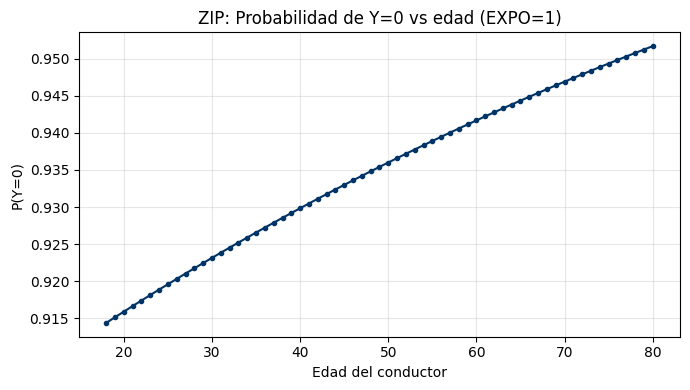

In [ ]:
# =========================================================
# Autor: Eric Daniel Hernández Jardón
# Código: Sobredispersión en los datos (R → Python)
# Tema: cómo elegir la distribución de la frecuencia
# Requisitos: pandas, numpy, matplotlib, statsmodels (>=0.14), patsy
# Entrada: data/base_trabajo.pkl (o .RDS con pyreadr)
# =========================================================
#%%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix
from scipy.stats import norm

# (Opcional) para leer .RDS si no tienes el PKL
try:
    import pyreadr
except Exception:
    pyreadr = None

# ---------------------------------------------------------
# 0) Carga de datos
# ---------------------------------------------------------
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(BASE_DIR, "data") # Original line
pkl_path = os.path.join(DATA_DIR, "base_trabajo.pkl") # Original line
rds_path = os.path.join(DATA_DIR, "base_trabajo.RDS") # Original line
# pkl_path = os.path.join(BASE_DIR, "base_trabajo.pkl")
# rds_path = os.path.join(BASE_DIR, "base_trabajo.RDS")

if os.path.exists(pkl_path):
    base_trabajo = pd.read_pickle(pkl_path)
elif os.path.exists(rds_path) and pyreadr is not None:
    obj = pyreadr.read_r(rds_path)
    base_trabajo = list(obj.values())[0]
else:
    raise FileNotFoundError("No encontré data/base_trabajo.pkl ni .RDS")

# Asegurar tipos clave si vinieron como object
# base_trabajo["EXPO"] = base_trabajo["EXPO"].astype(float)
# base_trabajo["num_sin"] = base_trabajo["num_sin"].astype(int)

color = "#003366"
fill = "#99CCFF"

# ---------------------------------------------------------
# 1) Nivel total: m_N, s2_N, dispersión = s2_N / m_N
# ---------------------------------------------------------
sum_expo = base_trabajo["EXPO"].sum()
m_N = base_trabajo["num_sin"].sum() / sum_expo  # weighted.mean(num_sin/EXPO, EXPO)
s2_N = ((base_trabajo["num_sin"] - m_N * base_trabajo["EXPO"])**2).sum() / sum_expo
disp_total = s2_N / m_N
print({"m_N": m_N, "s2_N": s2_N, "dispersion": disp_total})

# ---------------------------------------------------------
# 2) Por variable (COMBUSTIBLE) y por EDAD_CONDUCTOR
# ---------------------------------------------------------
def freq_stats(g: pd.DataFrame) -> pd.Series:
    expo = g["EXPO"].sum()
    mN = g["num_sin"].sum() / expo if expo > 0 else np.nan
    s2N = ((g["num_sin"] - mN * g["EXPO"])**2).sum() / expo if expo > 0 else np.nan
    disp = s2N / mN if (mN is not None and mN > 0) else np.nan
    return pd.Series({"m_N": mN, "s2_N": s2N, "expo": expo, "dispersion": disp})

if "COMBUSTIBLE" in base_trabajo.columns:
    eda_variable = (base_trabajo
                    .groupby("COMBUSTIBLE", dropna=False)
                    .apply(freq_stats, include_groups=False)
                    .reset_index())
    print("\n[EDA por COMBUSTIBLE]\n", eda_variable.head())

eda_edad = (base_trabajo
            .groupby("EDAD_CONDUCTOR", dropna=False)
            .apply(freq_stats, include_groups=False)
            .reset_index())

# Scatter Media vs Varianza con línea y=x
fig, ax = plt.subplots(figsize=(6, 5))
sizes = 50 * (eda_edad["expo"] / eda_edad["expo"].max()) + 20
ax.scatter(eda_edad["m_N"], eda_edad["s2_N"], s=sizes, c=fill, edgecolors=color)
lim = float(np.nanmax([eda_edad["m_N"].max(), eda_edad["s2_N"].max()])) * 1.05
ax.plot([0, lim], [0, lim], color=color, linestyle="--", linewidth=1)
ax.set_xlabel("Media m_N")
ax.set_ylabel("Varianza s2_N")
ax.set_title("Media vs Varianza (esperado Poisson: y = x)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()

# ---------------------------------------------------------
# 3) ¿Pendiente ≈ 1? Regresión s2_N ~ 0 + m_N (WLS con pesos=expo)
# ---------------------------------------------------------
X = eda_edad[["m_N"]].values
y = eda_edad["s2_N"].values
w = eda_edad["expo"].values

wls_model = sm.WLS(y, X, weights=w).fit()  # sin intercepto
print("\n[WLS] s2_N ~ 0 + m_N, pesos=expo")
print(wls_model.summary())

# Test H0: beta_mN = 1 (Wald)
beta = wls_model.params[0]
se_beta = wls_model.bse[0]
z_stat = (beta - 1.0) / se_beta
p_value = 2 * (1 - norm.cdf(abs(z_stat)))
print(f"Prueba H0: beta_mN = 1 → z = {z_stat:.3f}, p = {p_value:.4f}")

# ---------------------------------------------------------
# 4) Poisson con offset: num_sin ~ EDAD_CONDUCTOR + offset(log(EXPO))
# ---------------------------------------------------------
regpoisson = smf.glm(
    formula="num_sin ~ EDAD_CONDUCTOR",
    data=base_trabajo,
    family=sm.families.Poisson(),
    offset=np.log(base_trabajo["EXPO"])
).fit()
print("\n[GLM Poisson] con offset log(EXPO)")
print(regpoisson.summary())

# Chequeos de sobredispersión
pearson_chi2 = regpoisson.pearson_chi2   # sum(resid_pearson^2)
df_resid = regpoisson.df_resid
ratio_pearson = pearson_chi2 / df_resid
ratio_deviance = regpoisson.deviance / df_resid
print({"Pearson/df": ratio_pearson, "Deviance/df": ratio_deviance})

# ---------------------------------------------------------
# 5) Quasi-Poisson: mismos betas, SE ajustados por escala (Pearson/df)
# ---------------------------------------------------------
scale_qp = max(ratio_pearson, 1.0)  # factor de escala (>=1)
cov_qp = regpoisson.cov_params() * scale_qp
se_qp = np.sqrt(np.diag(cov_qp))
print("\n[Quasi-Poisson] mismos coeficientes que Poisson, SE ajustados:")
for name, b, se in zip(regpoisson.params.index, regpoisson.params.values, se_qp):
    print(f"  {name:>20s}: beta={b: .6f}, se_qp={se: .6f}")

# ---------------------------------------------------------
# 6) Zero-Inflated Poisson (ZIP) con exposure (corrección)
# ---------------------------------------------------------
zip_available = False
try:
    from statsmodels.discrete.count_model import ZeroInflatedPoisson
    zip_available = True
except Exception:
    pass

if zip_available:
    # Parte Poisson y parte de inflación (logit)
    exog = sm.add_constant(base_trabajo[["EDAD_CONDUCTOR"]])
    exog_infl = sm.add_constant(base_trabajo[["EDAD_CONDUCTOR"]])
    exposure = base_trabajo["EXPO"].values  # equivalente a offset(log(EXPO))

    zip_mod = ZeroInflatedPoisson(
        endog=base_trabajo["num_sin"].values,
        exog=exog,
        exog_infl=exog_infl,
        exposure=exposure,       # <<< USAR exposure (NO exog_scale)
        inflation='logit'
    )
    zip_res = zip_mod.fit(disp=False, method="bfgs", maxiter=200)
    print("\n[ZIP] Zero-Inflated Poisson (logit inflación) con exposure=EXPO")
    print(zip_res.summary())

    # Probabilidad de cero reclamos por edad (EXPO=1 para ilustrar)
    datos_prueba = pd.DataFrame({"EDAD_CONDUCTOR": np.arange(18, 81)})
    exog_new = sm.add_constant(datos_prueba[["EDAD_CONDUCTOR"]])
    exog_infl_new = sm.add_constant(datos_prueba[["EDAD_CONDUCTOR"]])

    pred_zero = zip_res.predict(
        exog=exog_new,
        exog_infl=exog_infl_new,
        which='prob-zero',
        exposure=np.ones(len(datos_prueba))  # <<< EXPO=1 en predicción
    )

    plt.figure(figsize=(7, 4))
    plt.plot(datos_prueba["EDAD_CONDUCTOR"], pred_zero, color=color, marker="o", ms=3)
    plt.title("ZIP: Probabilidad de Y=0 vs edad (EXPO=1)")
    plt.xlabel("Edad del conductor")
    plt.ylabel("P(Y=0)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
else:
    print("\n[ZIP] Requiere statsmodels>=0.14 (ZeroInflatedPoisson).")

# ---------------------------------------------------------
# 7) Binomial Negativa
# ---------------------------------------------------------
# (A) GLM NB con alpha fijo (heurística por sobredispersión)
from statsmodels.genmod.families import NegativeBinomial
alpha_guess = max(ratio_pearson - 1.0, 1e-6)  # heurística simple
regnb_glm = smf.glm(
    formula="num_sin ~ EDAD_CONDUCTOR",
    data=base_trabajo,
    family=NegativeBinomial(alpha=alpha_guess),
    offset=np.log(base_trabajo["EXPO"])
).fit()
print("\n[GLM NB] (alpha fijo ~ heurística por sobredispersión)")
print(regnb_glm.summary())

# (B) NB2 discreto (estima parámetro de dispersión), si disponible
try:
    from statsmodels.discrete.count_model import NegativeBinomialP
    exog_nb = sm.add_constant(base_trabajo[["EDAD_CONDUCTOR"]])
    nb_mod = NegativeBinomialP(
        endog=base_trabajo["num_sin"].values,
        exog=exog_nb,
        loglike_method='nb2'
    )
    nb_res = nb_mod.fit(disp=False, method="bfgs", maxiter=200)
    print("\n[NB2 discreto] (estima parámetro de dispersión)")
    print(nb_res.summary())
except Exception as e:
    print("\n[NB2 discreto] No disponible o falló la optimización.")
    print("Detalle:", e)

plt.show()

Explica qué significa sobredispersión y cómo se detecta en el código.

In [ ]:
"""
La sobredispersión implica que el valor de la varianza excede la media.
Esta se puede detectar cuando los cocientes Perason/df y Deviance/df son mayores a 1.
Bajo esta idea, si dichos coeficientes son valores cercanos a 1, esto implica un buen ajuste Poisson.
"""

# Ajustamos un GLM Poisson con offset log(EXPO)

regpoisson = smf.glm(
    formula="num_sin ~ EDAD_CONDUCTOR",
    data=base_trabajo,
    family=sm.families.Poisson(),
    offset=np.log(base_trabajo["EXPO"])
).fit()


# Ahora calculamos los indicadores sobre dispersión

pearson_chi2 = regpoisson.pearson_chi2
df_resid = regpoisson.df_resid
ratio_pearson = pearson_chi2 / df_resid
ratio_deviance = regpoisson.deviance /df_resid


# Imprimimos resultados y comprobamos sobredispersión
print({"Perason/df": ratio_pearson, "Deviance/df": ratio_deviance})


{'Perason/df': np.float64(1.9365681030658053), 'Deviance/df': np.float64(0.2528583349165023)}


*   En este caso tenemos que **Pearson/df = 1.93**, implicando que existe sobredispersión, pues la varianza observada es casi el doble de la media, lo que implica que el modelo subestima la variabilidad real de los datos
*   Por otro lado, **Deviance/df = 0.25**, sugiriendo que el modelo está sobreajustando, o bien que los residuos son más pequeños de lo esperado. Esto llega a suceder cuando la estructura del modelo captura bien la tendencia central



Si en una cartera de autos los asegurados jóvenes generan mucha varianza en la frecuencia, ¿qué modelo alternativo recomendarías y por qué?

In [ ]:
"""
Utilizando el mismo método para estandarizar y comparar la dispersión entre los modelos,
nos permite elegir aquel que objetivamente es mejor. Procurando valorar el ajuste y la capacidad del modelo de capturar variabilidad.
"""

resultados_dispersion = {}

# 1. Poisson
reg_poisson = smf.glm(
    formula="num_sin ~ EDAD_CONDUCTOR",
    data=base_trabajo,
    family=sm.families.Poisson(),
    offset=np.log(base_trabajo["EXPO"])
).fit()
pearson_poisson = reg_poisson.pearson_chi2 / reg_poisson.df_resid
deviance_poisson = reg_poisson.deviance / reg_poisson.df_resid
resultados_dispersion["Poisson"] = {"Pearson/df": pearson_poisson, "Deviance/df": deviance_poisson}

# 2. Quasi-Poisson (usando Pearson/df como factor de escala)
scale_qp = max(pearson_poisson, 1.0)
resultados_dispersion["Quasi-Poisson"] = {"Scale factor": scale_qp}

# 3. Zero-Inflated Poisson (adaptamos dado que no tiene la misma estructura de un GLM "normal")
# Predicciones esperadas bajo ZIP
mu_zip = zip_res.predict(which="mean")

# Residuos Pearson = (observado - esperado) / sqrt(esperado)
resid_pearson_zip = (base_trabajo["num_sin"].values - mu_zip) / np.sqrt(mu_zip)

# Pearson chi2 = suma de residuos Pearson^2
pearson_chi2_zip = np.sum(resid_pearson_zip**2)

# Cociente Pearson/df
ratio_pearson_zip = pearson_chi2_zip / zip_res.df_resid


# 4. Binomial Negativa
from statsmodels.genmod.families import NegativeBinomial
alpha_guess = max(pearson_poisson - 1.0, 1e-6)
reg_nb = smf.glm(
    formula="num_sin ~ EDAD_CONDUCTOR",
    data=base_trabajo,
    family=NegativeBinomial(alpha=alpha_guess),
    offset=np.log(base_trabajo["EXPO"])
).fit()
pearson_nb = reg_nb.pearson_chi2 / reg_nb.df_resid
deviance_nb = reg_nb.deviance / reg_nb.df_resid
resultados_dispersion["Binomial Negativa"] = {"Pearson/df": pearson_nb, "Deviance/df": deviance_nb}

# Mostrar resultados comparativos
print("\nComparación de dispersión entre modelos:")
for modelo, valores in resultados_dispersion.items():
    print(modelo, "→", valores)
print("ZIP → Perason/df:", ratio_pearson_zip)




Comparación de dispersión entre modelos:
Poisson → {'Pearson/df': np.float64(1.9365681030658053), 'Deviance/df': np.float64(0.2528583349165023)}
Quasi-Poisson → {'Scale factor': np.float64(1.9365681030658053)}
Binomial Negativa → {'Pearson/df': np.float64(1.8829437693909312), 'Deviance/df': np.float64(0.22285788611545243)}
ZIP → Perason/df: 1.9153692810528502


Analizando estos resultados inferimos lo siguiente:



*   **Poisson**. Muestra sobredispersión clara y una devianza baja, indicando que el modelo capta la tendencia central y subestima la variabilidad.
*   **Quasi-Poisson**. Usa el mismo coeficiente de la Poisson, pero ajusta los errores estándar por el factor de escala. Corrige la inferencia pero no cambia la estructura del modelo o  captura la sobredispersión explícitamente.
*   **ZIP**. Sugiere que el modelo ayuda a manejar el exceso de ceros, pero mantiene una alta dispersión.
*   **Binomial Negativa**. Es el que más se acerca a controlar la sobredispersión, ya que introduce un parámetro de dispersión adicional que ajusta la varianza.

De este modo, para una cartera de autos donde los asegudaros jóvenes generan mucha varianza en la frec uecnia, el modelo más adecuado es la **Binomial Negativa** ya que captura la dispersión adicional y refleja mejor la realidad de la cartera.
